# Bench Engine Demo: MalthusJAXBenchEngine vs EvosaxBenchEngine

This notebook demonstrates how to use `tests/benchmarks/conftest_benchmarks.py` to compare the two benchmark engines via `_run_comparison` and `_run_parity_comparison`.
It also shows how to inspect the returned experiment histories for both frameworks.

In [1]:
import sys

sys.path.append("..")
from tests.benchmarks.conftest_benchmarks import (
    _run_comparison,
    _run_parity_comparison,
)

print("Imports OK")

Imports OK


## Comparison using `_run_comparison`

`_run_comparison` runs both benchmark engines with the same configuration, but without forcing canonical initialisation.
This is useful for comparing normal benchmark behavior in each framework.

In [2]:
pop_size = 50
dims = 10
problem = "ellipsoidal"
num_generations = 50
seeds = (42, 123)

comparison_result = _run_comparison(
    pop_size=pop_size,
    dims=dims,
    problem=problem,
    num_generations=num_generations,
    seeds=seeds,
)

print("Comparison result ready")

seeds: 100%|██████████| 2/2 [00:02<00:00,  1.40s/it]

Comparison result ready


In [3]:
def print_pipeline_summary(name, pipeline):
    print(f"--- {name} ---")
    print(f"Number of seeds: {len(pipeline.runs)}")
    for run in pipeline.runs:
        print(f"  seed={run.seed} status={run.status}")
        history = run.history
        print(f"    generations={len(history)} start={history[0]} end={history[-1]}")
    print()


print_pipeline_summary("MalthusJAX", comparison_result.pipelines["malthusjax"])
print_pipeline_summary("Evosax", comparison_result.pipelines["evosax"])

--- MalthusJAX ---
Number of seeds: 2
  seed=42 status=success
    generations=50 start={'generation': 1, 'best_fitness': -697330.375, 'mean_fitness': -5851125.5} end={'generation': 50, 'best_fitness': -8903.2705078125, 'mean_fitness': -16959.08984375}
  seed=123 status=success
    generations=50 start={'generation': 1, 'best_fitness': -681761.9375, 'mean_fitness': -7984481.0} end={'generation': 50, 'best_fitness': -4902.9404296875, 'mean_fitness': -6182.8125}

--- Evosax ---
Number of seeds: 2
  seed=42 status=success
    generations=50 start={'generation': 1, 'best_fitness': -599744.4375, 'mean_fitness': -16556451.0} end={'generation': 50, 'best_fitness': -29022.58984375, 'mean_fitness': -1773103.625}
  seed=123 status=success
    generations=50 start={'generation': 1, 'best_fitness': -135350.9375, 'mean_fitness': -12485602.0} end={'generation': 50, 'best_fitness': -59344.68359375, 'mean_fitness': -3065537.25}



## Parity comparison using `_run_parity_comparison`

`_run_parity_comparison` forces both engines to start from the same canonical population.
This is the cleanest way to compare the engine behaviors directly, isolating differences to the evolution operators rather than random initialisation.

In [4]:
parity_result = _run_parity_comparison(
    pop_size=pop_size,
    dims=dims,
    problem=problem,
    num_generations=num_generations,
    seeds=seeds,
    use_evosax_ops=True,
)

print("Parity result ready")

seeds: 100%|██████████| 2/2 [00:01<00:00,  1.07it/s]

Parity result ready


In [5]:
print_pipeline_summary("MalthusJAX (parity)", parity_result.pipelines["malthusjax"])
print_pipeline_summary("Evosax (parity)", parity_result.pipelines["evosax"])

--- MalthusJAX (parity) ---
Number of seeds: 2
  seed=42 status=success
    generations=50 start={'generation': 1, 'best_fitness': -1406211.5, 'mean_fitness': -19118056.0} end={'generation': 50, 'best_fitness': -4676.13671875, 'mean_fitness': -25532.8203125}
  seed=123 status=success
    generations=50 start={'generation': 1, 'best_fitness': -532201.5, 'mean_fitness': -20865736.0} end={'generation': 50, 'best_fitness': -8352.3203125, 'mean_fitness': -27427.109375}

--- Evosax (parity) ---
Number of seeds: 2
  seed=42 status=success
    generations=50 start={'generation': 1, 'best_fitness': -599744.4375, 'mean_fitness': -16556451.0} end={'generation': 50, 'best_fitness': -29022.58984375, 'mean_fitness': -1773103.625}
  seed=123 status=success
    generations=50 start={'generation': 1, 'best_fitness': -135350.9375, 'mean_fitness': -12485602.0} end={'generation': 50, 'best_fitness': -59344.68359375, 'mean_fitness': -3065537.25}



## Compare histories side-by-side

The example below prints matching seed histories for both pipelines from the parity comparison result.

In [6]:
for mjx_run, esx_run in zip(
    parity_result.pipelines["malthusjax"].runs, parity_result.pipelines["evosax"].runs
):
    assert mjx_run.seed == esx_run.seed
    print(f"Seed {mjx_run.seed}")
    print("  MalthusJAX history:")
    for entry in mjx_run.history:
        print("   ", entry)
    print("  Evosax history:")
    for entry in esx_run.history:
        print("   ", entry)
    print()

Seed 42
  MalthusJAX history:
    {'generation': 1, 'best_fitness': -1406211.5, 'mean_fitness': -19118056.0}
    {'generation': 2, 'best_fitness': -1082035.375, 'mean_fitness': -5353523.0}
    {'generation': 3, 'best_fitness': -975621.875, 'mean_fitness': -3005330.25}
    {'generation': 4, 'best_fitness': -447095.28125, 'mean_fitness': -1984211.5}
    {'generation': 5, 'best_fitness': -394965.65625, 'mean_fitness': -1519410.25}
    {'generation': 6, 'best_fitness': -354557.375, 'mean_fitness': -1071296.25}
    {'generation': 7, 'best_fitness': -500112.03125, 'mean_fitness': -811412.8125}
    {'generation': 8, 'best_fitness': -132917.109375, 'mean_fitness': -607699.75}
    {'generation': 9, 'best_fitness': -246387.828125, 'mean_fitness': -537221.6875}
    {'generation': 10, 'best_fitness': -196411.640625, 'mean_fitness': -469018.375}
    {'generation': 11, 'best_fitness': -126472.859375, 'mean_fitness': -378795.5}
    {'generation': 12, 'best_fitness': -54740.64453125, 'mean_fitness': -

<Axes: title={'center': 'Convergence comparison'}, xlabel='Generation', ylabel='Best Fitness'>

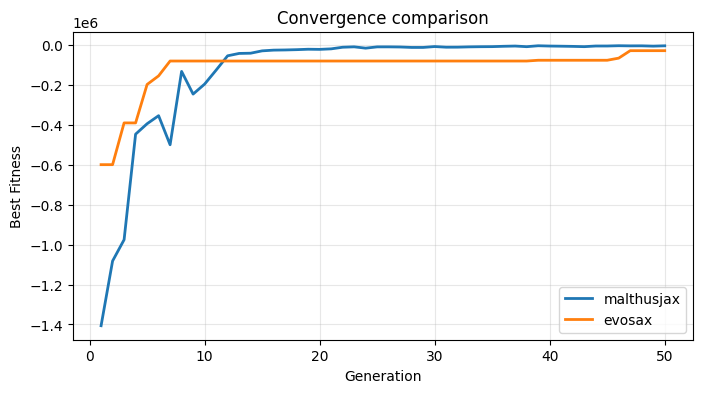

In [7]:
parity_result.plot_convergence(seed_index=0)

In [8]:
parity_result.convergence_data(seed_index=0)

{'malthusjax': [{'generation': 1,
   'best_fitness': -1406211.5,
   'mean_fitness': -19118056.0},
  {'generation': 2, 'best_fitness': -1082035.375, 'mean_fitness': -5353523.0},
  {'generation': 3, 'best_fitness': -975621.875, 'mean_fitness': -3005330.25},
  {'generation': 4, 'best_fitness': -447095.28125, 'mean_fitness': -1984211.5},
  {'generation': 5,
   'best_fitness': -394965.65625,
   'mean_fitness': -1519410.25},
  {'generation': 6, 'best_fitness': -354557.375, 'mean_fitness': -1071296.25},
  {'generation': 7,
   'best_fitness': -500112.03125,
   'mean_fitness': -811412.8125},
  {'generation': 8,
   'best_fitness': -132917.109375,
   'mean_fitness': -607699.75},
  {'generation': 9,
   'best_fitness': -246387.828125,
   'mean_fitness': -537221.6875},
  {'generation': 10,
   'best_fitness': -196411.640625,
   'mean_fitness': -469018.375},
  {'generation': 11,
   'best_fitness': -126472.859375,
   'mean_fitness': -378795.5},
  {'generation': 12,
   'best_fitness': -54740.64453125,
 